In [94]:
import numpy as np


def crop_sem_overlay(image,
                     top=0,
                     bottom=0,
                     left=0,
                     right=0):
    """
    Remove SEM annotations/scale bars.

    Pixels are removed from each edge.
    """

    h, w = image.shape

    cropped = image[
        top:h-bottom,
        left:w-right
    ]

    return cropped

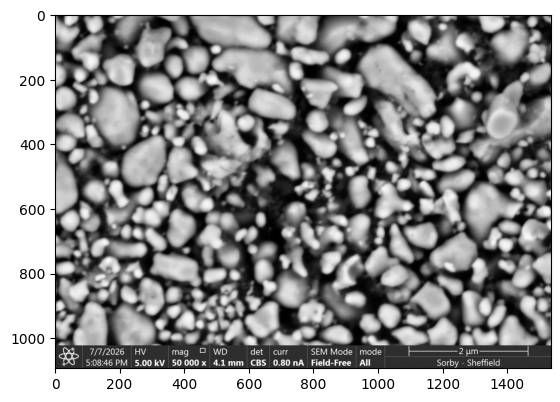

In [ ]:
import matplotlib.pyplot as plt
import tifffile


image = tifffile.imread(
    r"C:\PhD_programs\Opetemisation_data\FIB_SEM_optimization\images\raw\CBS_Fresh_LFP_33.tif"
)


plt.imshow(
    image,
    cmap="gray"
)

plt.axis("on")
plt.show()

In [96]:
crop = image[
    0:1010
]

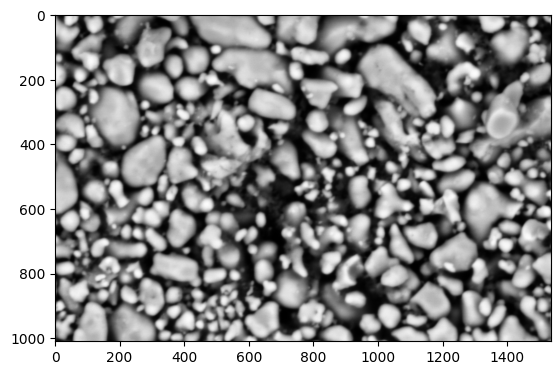

In [97]:
plt.imshow(
    crop,
    cmap="gray"
)

plt.axis("on")
plt.show()

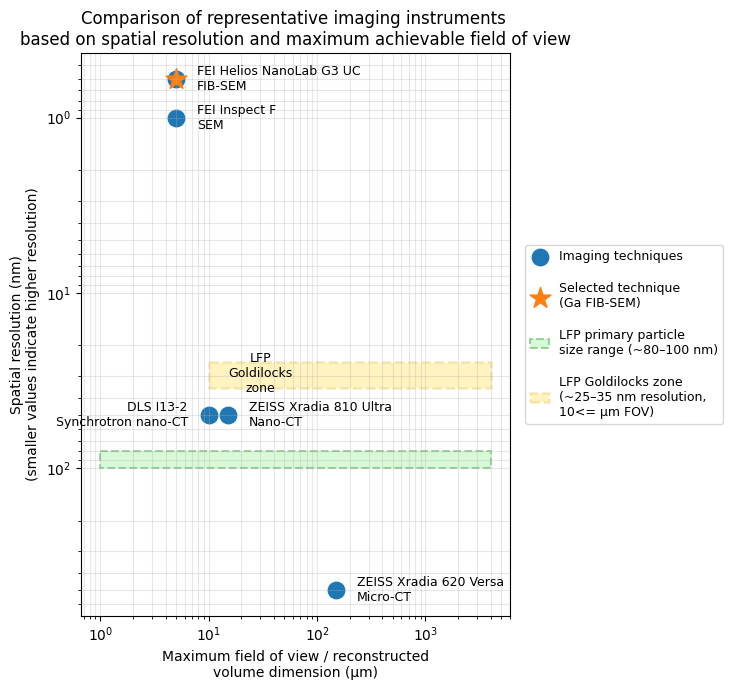

In [82]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# Specific instruments and approximate values

instruments = [
    "FEI Inspect F\nSEM",
    "FEI Helios NanoLab G3 UC\nFIB-SEM",
    "ZEISS Xradia 620 Versa\nMicro-CT",
    "ZEISS Xradia 810 Ultra\nNano-CT",
    "DLS I13-2\nSynchrotron nano-CT"
]


# Spatial resolution (nm)
# Lower value = higher resolution
resolution_nm = [
    1,
    0.6,
    500,
    50,
    50
]


# Maximum field of view / reconstructed volume dimension (µm)
field_of_view_um = [
    5,
    5,
    150,
    15,
    10
]


# Create figure

plt.figure(figsize=(10, 7))


# -------------------------------
# Plot imaging techniques
# -------------------------------

plt.scatter(
    field_of_view_um,
    resolution_nm,
    s=140,
    label="Imaging techniques"
)


# Add instrument labels

for i, name in enumerate(instruments):

    if i == 4:  # FIB-SEM label
        plt.annotate(
            name,
            (field_of_view_um[i], resolution_nm[i]),
            xytext=(-15, 0),
            textcoords="offset points",
            fontsize=9,
            va="center",
            ha="right"
        )
    else:
        plt.annotate(
            name,
            (field_of_view_um[i], resolution_nm[i]),
            xytext=(15, 0),
            textcoords="offset points",
            fontsize=9,
            va="center",
            ha="left"
        )


# -------------------------------
# Highlight selected technique
# -------------------------------

plt.scatter(
    field_of_view_um[1],
    resolution_nm[1],
    s=250,
    marker="*",
    label="Selected technique\n(Ga FIB-SEM)"
)


ax = plt.gca()


# -------------------------------
# LFP particle size range
# -------------------------------

lfp_min = 80
lfp_max = 100

lfp_box = patches.Rectangle(
    (1, lfp_min),
    4000,
    lfp_max - lfp_min,
    linewidth=1.5,
    edgecolor="green",
    facecolor="lightgreen",
    alpha=0.35,
    linestyle="--",
    label="LFP primary particle\nsize range (~80–100 nm)"
)

ax.add_patch(lfp_box)


# -------------------------------
# Goldilocks imaging zone
# -------------------------------

# 1/3 pixel rule:
# 80–100 nm particles require ~25–35 nm resolution

goldilocks_box = patches.Rectangle(
    (10, 25),
    4000,
    10,
    linewidth=1.8,
    edgecolor="goldenrod",
    facecolor="gold",
    alpha=0.25,
    linestyle="--",
    label="LFP Goldilocks zone\n(~25–35 nm resolution,\n10<= µm FOV)"
)

ax.add_patch(goldilocks_box)


# Add label inside Goldilocks zone

plt.text(
    30,
    29,
    "LFP\nGoldilocks\nzone",
    fontsize=9,
    ha="center",
    va="center"
)


# -------------------------------
# Axis formatting
# -------------------------------

plt.xscale("log")
plt.yscale("log")

# Smaller resolution = better
plt.gca().invert_yaxis()


plt.xlabel(
    "Maximum field of view / reconstructed\nvolume dimension (µm)"
)

plt.ylabel(
    "Spatial resolution (nm)\n(smaller values indicate higher resolution)"
)


plt.title(
    "Comparison of representative imaging instruments \n"
    "based on spatial resolution and maximum achievable field of view"
)


plt.grid(
    True,
    which="both",
    alpha=0.3
)


# -------------------------------
# Legend outside plot
# -------------------------------

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    frameon=True,
    handlelength=1.5,
    handletextpad=0.8,
    labelspacing=1.5,
    borderaxespad=0.5
)


# Leave space for legend

plt.tight_layout(
    rect=[0, 0, 0.75, 1]
)


plt.show()

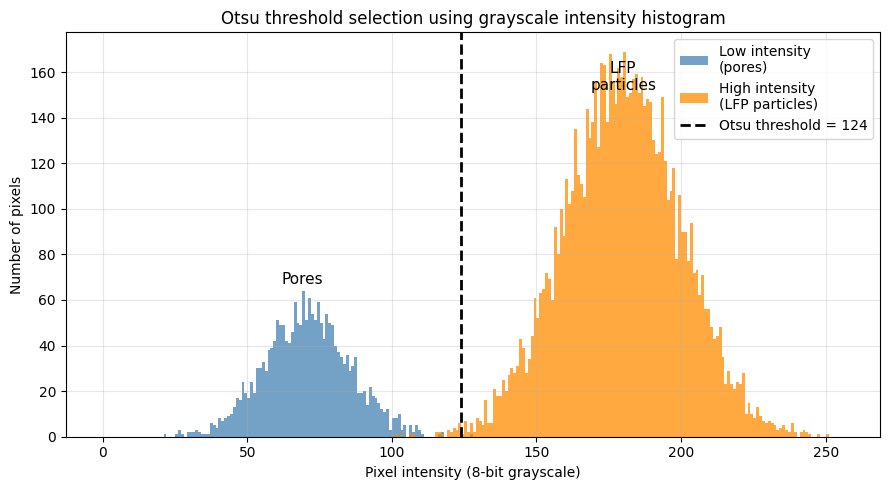

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu


# --------------------------------
# Synthetic SEM intensity classes
# --------------------------------

np.random.seed(42)

# Dark phase: pores/background
pores = np.random.normal(
    loc=70,
    scale=15,
    size=2000
)

# Bright phase: LFP particles
lfp = np.random.normal(
    loc=180,
    scale=20,
    size=8000
)


# Combine pixel intensities

pixels = np.clip(
    np.concatenate([pores, lfp]),
    0,
    255
)


# --------------------------------
# Otsu threshold
# --------------------------------

threshold = int(
    threshold_otsu(pixels)
)


# --------------------------------
# Plot histogram
# --------------------------------

fig, ax = plt.subplots(
    figsize=(9, 5)
)

bins = np.arange(257)


# Pores

ax.hist(
    pores,
    bins=bins,
    color="steelblue",
    alpha=0.75,
    label="Low intensity\n(pores)"
)


# LFP particles

ax.hist(
    lfp,
    bins=bins,
    color="darkorange",
    alpha=0.75,
    label="High intensity\n(LFP particles)"
)


# Otsu threshold

ax.axvline(
    threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Otsu threshold = {threshold}"
)


# --------------------------------
# Peak locations
# --------------------------------

pores_hist, pores_bins = np.histogram(
    pores,
    bins=bins
)

lfp_hist, lfp_bins = np.histogram(
    lfp,
    bins=bins
)


# Pore label at peak

ax.text(
    pores_bins[np.argmax(pores_hist)],
    max(pores_hist) * 1.05,
    "Pores",
    ha="center",
    fontsize=11
)


# LFP label 10% below peak

ax.text(
    lfp_bins[np.argmax(lfp_hist)],
    max(lfp_hist) * 0.90,
    "LFP\nparticles",
    ha="center",
    fontsize=11
)


# --------------------------------
# Formatting
# --------------------------------

ax.set_xlabel(
    "Pixel intensity (8-bit grayscale)"
)

ax.set_ylabel(
    "Number of pixels"
)

ax.set_title(
    "Otsu threshold selection using grayscale intensity histogram"
)

ax.grid(
    alpha=0.3
)

ax.legend(
    frameon=True
)


plt.tight_layout()

plt.show()